# RetailPulse AI – Day 1: Exploratory Data Analysis

### Prepared By: Bansi Kanani

### Date: 29 May 2026

# Introduction

The Online Retail II dataset contains transactional sales records from a UK-based online retailer.

This notebook focuses on performing Exploratory Data Analysis (EDA) to understand customer purchasing behavior, product demand patterns, and overall data quality before building machine learning models.

# Objective

The objectives of Day 1 are:

- Understand dataset structure
- Analyze data quality
- Identify missing values
- Explore customer and product behavior
- Generate business insights
- Prepare for feature engineering

# Project Overview

RetailPulse AI is an AI-powered retail analytics platform designed to help businesses:

- Understand customer purchasing behavior
- Forecast future sales demand
- Segment customers using RFM analysis
- Predict customer churn
- Optimize inventory management

The project uses the Online Retail II dataset as the primary data source.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("archive (3)/online_retail_II.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# Dataset Shape

The dataset shape provides the total number of rows and columns available for analysis.

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1067371
Columns: 8


# Dataset Information

This section provides information about column names, data types, and non-null values.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


# Missing Value Analysis

Identifying missing values helps understand data quality and highlights areas requiring preprocessing.

In [5]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

# Statistical Summary

Statistical measures provide insight into numerical distributions and potential outliers.

In [6]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


# Revenue Feature Creation

Revenue is calculated as:

Revenue = Quantity × Price

This feature will be used throughout the project for sales and customer analysis.

In [7]:
df["Revenue"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


# Revenue Distribution

Analyzing revenue distribution helps identify sales patterns and extreme transaction values.

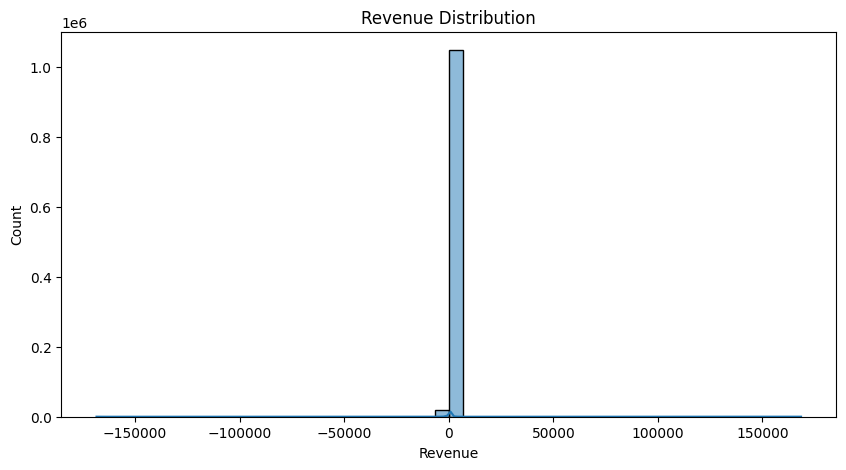

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Revenue"],
    bins=50,
    kde=True
)

plt.title("Revenue Distribution")

plt.show()

# Country Analysis

This analysis identifies countries contributing the highest number of retail transactions.

In [9]:
top_countries = (
    df["Country"]
    .value_counts()
    .head(10)
)

top_countries

Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64

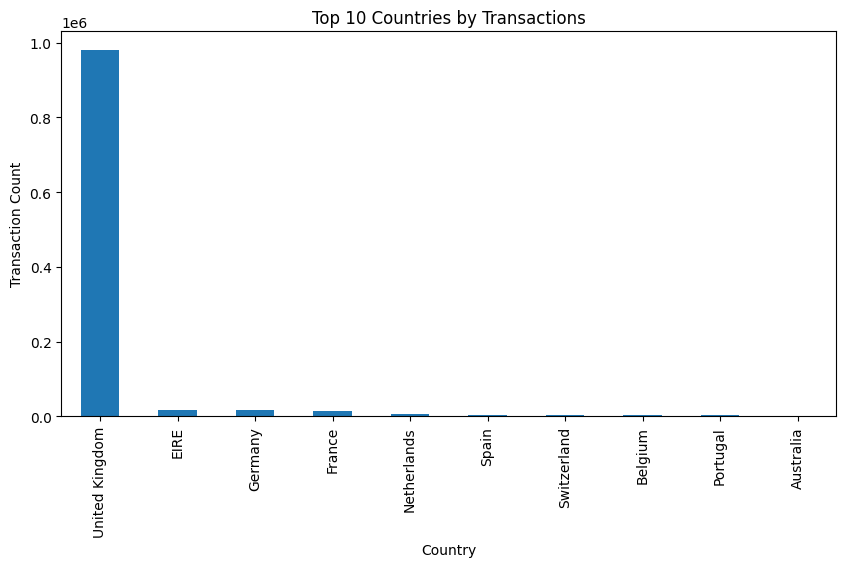

In [10]:
plt.figure(figsize=(10,5))

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Transactions")
plt.ylabel("Transaction Count")

plt.show()

# Product Analysis

Understanding top-selling products helps identify high-demand items and provides valuable insights for inventory planning and forecasting.

In [11]:
top_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     108545
WHITE HANGING HEART T-LIGHT HOLDER     93050
ASSORTED COLOUR BIRD ORNAMENT          81306
JUMBO BAG RED RETROSPOT                78090
BROCADE RING PURSE                     70700
PACK OF 60 PINK PAISLEY CAKE CASES     56575
60 TEATIME FAIRY CAKE CASES            54366
SMALL POPCORN HOLDER                   49616
PACK OF 72 RETROSPOT CAKE CASES        49344
PACK OF 72 RETRO SPOT CAKE CASES       46106
Name: Quantity, dtype: int64

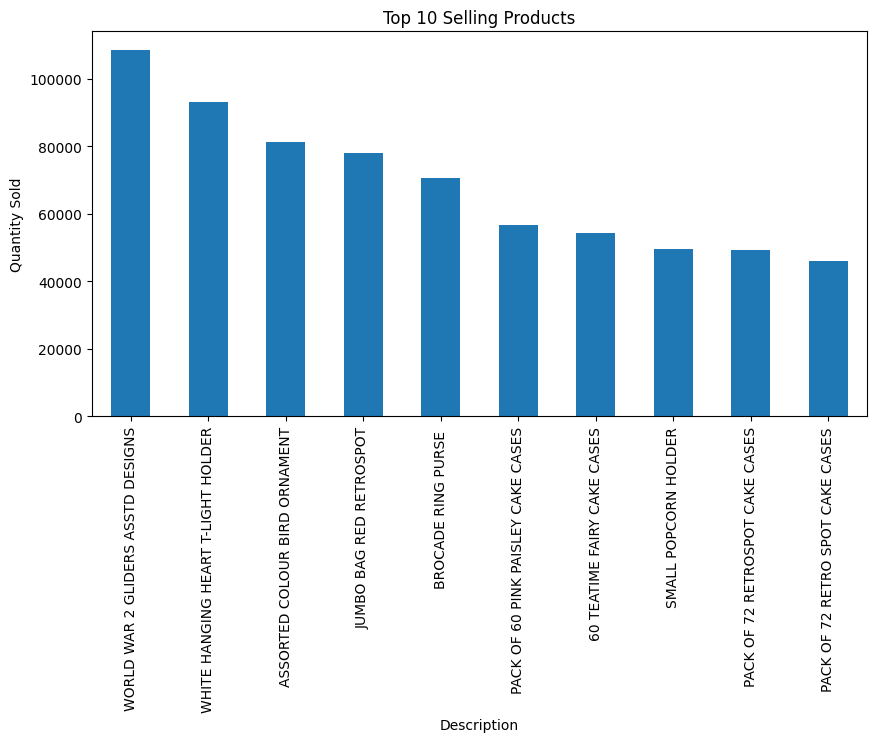

In [12]:
plt.figure(figsize=(10,5))

top_products.plot(kind="bar")

plt.title("Top 10 Selling Products")
plt.ylabel("Quantity Sold")

plt.show()

# Customer Analysis

Customer analysis helps understand the size of the customer base and provides insights into customer purchasing behavior.

In [13]:
total_customers = df["Customer ID"].nunique()

print("Total Unique Customers:", total_customers)

Total Unique Customers: 5942


# Revenue by Country

This analysis identifies countries generating the highest revenue for the business.

In [14]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

Country
United Kingdom    1.638258e+07
EIRE              6.155196e+05
Netherlands       5.485249e+05
Germany           4.179886e+05
France            3.281918e+05
Australia         1.671291e+05
Switzerland       9.972876e+04
Spain             9.185948e+04
Sweden            8.780942e+04
Denmark           6.574109e+04
Name: Revenue, dtype: float64

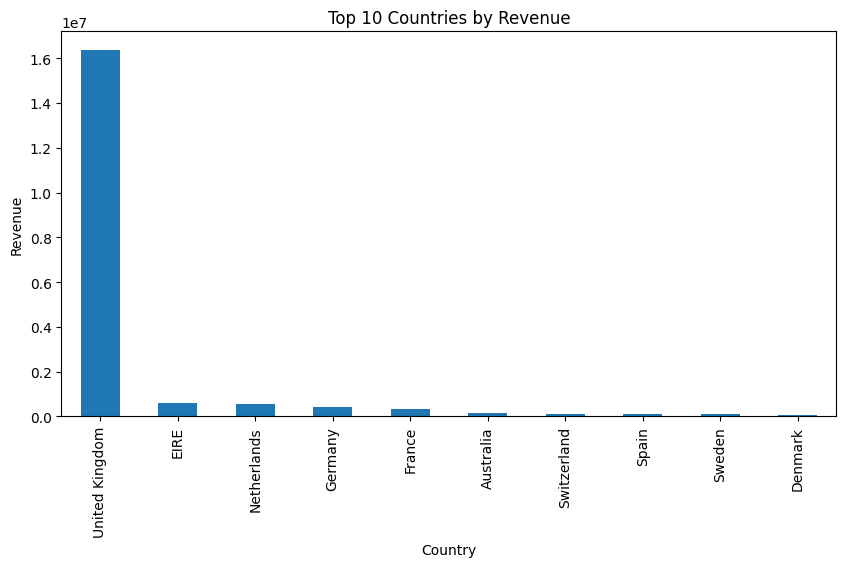

In [15]:
plt.figure(figsize=(10,5))

country_revenue.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")

plt.show()

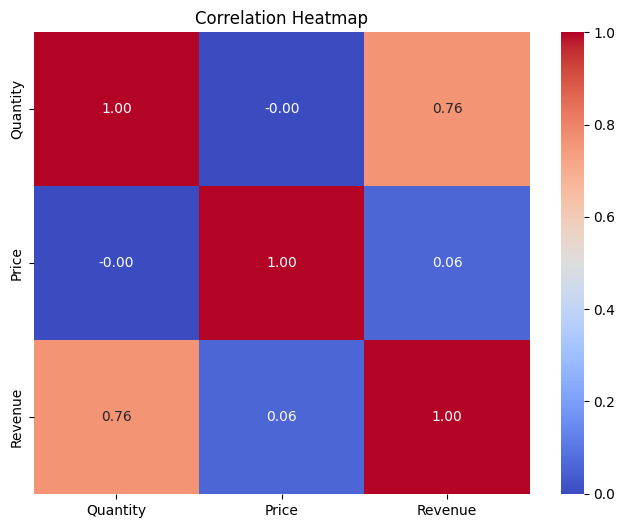

In [16]:
# Add this after your statistical summary section
plt.figure(figsize=(8,6))
numeric_cols = df[["Quantity", "Price", "Revenue"]].corr()
sns.heatmap(numeric_cols, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Key Business Insights

1. The dataset contains over one million retail transactions across multiple countries.

2. The United Kingdom contributes the majority of transactions and revenue.

3. Several products consistently generate high sales volumes, indicating strong customer demand.

4. Customer purchasing behavior varies significantly across regions.

5. Revenue distribution highlights the presence of high-value transactions and potential outliers.

These insights provide a strong foundation for customer segmentation, forecasting, churn prediction, and inventory optimization.

# Challenges Faced

The dataset contains missing customer identifiers and a large transaction volume, requiring careful analysis and validation.

Understanding transaction-level data across multiple countries and products was important before proceeding to feature engineering and machine learning tasks.

# Conclusion

Exploratory Data Analysis was successfully performed on the Online Retail II dataset.

The analysis provided valuable insights into customer behavior, product demand, revenue patterns, and data quality. These findings establish a strong foundation for feature engineering, customer segmentation, forecasting, and advanced analytics in subsequent project phases.